# UJIAN AKHIR SEMESTER GENAP 2024/2025
## mata Kuliah: Pembelajaran Mesin
### Dosen: Abu Salam, M.Kom

### **Nama:** [Abdul Khalim]
### **NIM:** [A11.2023.15327] 
### **Kelas:** A11.4402

# Dengue Fever Cases 2021 Dataset

Analyze dengue hemorrhagic fever (DHF) case counts in 2021 and build a simple risk classification model based on aggregated patient data.

Link Dataset: Internal resource `https://data.jatengprov.go.id/dataset/tabel-21`

## Ringkasan dan Permasalahan project + Tujuan yang akan dicapai + Model/Alur Penyelesaian


Project ini bertujuan untuk membangun model klasifikasi sederhana untuk mengelompokkan kecamatan di Kabupaten Purbalingga berdasarkan risiko kasus Demam Berdarah Dengue (DBD) pada tahun 2021. Dataset berisi 22 observasi (masing‑masing kecamatan) dengan informasi jumlah pasien laki‑laki, perempuan, dan kematian.

**Permasalahan utama**

* Jumlah data sangat kecil (hanya 22 baris) sehingga risiko overfitting tinggi.
* Tidak tersedia variabel penjelas lain (mis. kepadatan penduduk, iklim) sehingga fitur harus direkayasa dari data yang ada.
* Distribusi target (risiko tinggi vs rendah) dapat tidak seimbang.

**Alur penyelesaian**

1. **Pengumpulan & Pemuatan Data** – membaca berkas CSV lokal.  
2. **Pra‑proses & Rekayasa Fitur**  
   * Menghitung total kasus dan total kematian tiap kecamatan.  
   * Menetapkan label `risk` (High/Low) berdasarkan median total kasus.  
3. **Pembagian Data** – train‑test split 80‑20 dengan stratifikasi.  
4. **Pemodelan** – baseline `LogisticRegression`; dibandingkan dengan `RandomForestClassifier`.  
5. **Evaluasi** – accuracy, precision, recall, f1‑score.  
6. **Interpretasi** – pentingnya fitur & rekomendasi tindakan lanjut.

Tujuan akhirnya adalah menyediakan *proof‑of‑concept* pipeline ML yang bisa diperluas dengan fitur eksternal (cuaca, kepadatan penduduk) untuk akurasi yang lebih baik di masa depan.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load dataset
df = pd.read_csv('tahun-2021-data-kasus-demam-berdarah.csv')
print("Preview data:")
print(df.head())


Preview data:
  Kode Kecamatan Nama Kecamatan UPT Puskesmas  Jumlah Pasien Laki - laki  \
0       33.03.01      Kemangkon     Kemangkon                          3   
1       33.03.02       Bukateja      Bukateja                          1   
2       33.03.02       Bukateja       Kutawis                          1   
3       33.03.03       Kejobong      Kejobong                          3   
4       33.03.16     Pengadegan    Pengadegan                          1   

   Jumlah Pasien Perempuan  Jumlah Pasien Meninggal Laki - laki  \
0                        0                                    1   
1                        1                                    0   
2                        1                                    0   
3                        1                                    0   
4                        1                                    0   

   Jumlah Pasien Meninggal Perempuan  
0                                  0  
1                                  0  
2        

In [3]:
# EDA - Data Shape and Info
print("\nData shape:", df.shape)
print("\nData info:")
print(df.info())


Data shape: (22, 7)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Kode Kecamatan                       22 non-null     object
 1   Nama Kecamatan                       22 non-null     object
 2   UPT Puskesmas                        22 non-null     object
 3   Jumlah Pasien Laki - laki            22 non-null     int64 
 4   Jumlah Pasien Perempuan              22 non-null     int64 
 5   Jumlah Pasien Meninggal Laki - laki  22 non-null     int64 
 6   Jumlah Pasien Meninggal Perempuan    22 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 1.3+ KB
None


In [4]:
# EDA - Missing Values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Kode Kecamatan                         0
Nama Kecamatan                         0
UPT Puskesmas                          0
Jumlah Pasien Laki - laki              0
Jumlah Pasien Perempuan                0
Jumlah Pasien Meninggal Laki - laki    0
Jumlah Pasien Meninggal Perempuan      0
dtype: int64


In [5]:
# EDA - Descriptive Statistics
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
       Jumlah Pasien Laki - laki  Jumlah Pasien Perempuan  \
count                  22.000000                22.000000   
mean                    2.545455                 1.863636   
std                     2.539728                 2.210267   
min                     0.000000                 0.000000   
25%                     1.000000                 0.250000   
50%                     2.000000                 1.000000   
75%                     3.000000                 2.750000   
max                    10.000000                 9.000000   

       Jumlah Pasien Meninggal Laki - laki  Jumlah Pasien Meninggal Perempuan  
count                            22.000000                          22.000000  
mean                              0.090909                           0.136364  
std                               0.294245                           0.351250  
min                               0.000000                           0.000000  
25%                      

In [9]:
# Feature Engineering - Total Cases
df['Total_Pasien'] = df['Jumlah Pasien Laki - laki'] + df['Jumlah Pasien Perempuan']
df['Total_Meninggal'] = df['Jumlah Pasien Meninggal Laki - laki'] + df['Jumlah Pasien Meninggal Perempuan']
df['Tingkat_Kematian'] = df['Total_Meninggal'] / df['Total_Pasien'] * 100
df['Tingkat_Kematian'] = df['Tingkat_Kematian'].fillna(0)
df['Tingkat_Kematian'] = (df['Total_Meninggal'] / df['Total_Pasien'] * 100).fillna(0)
df['Rasio_Gender'] = df['Jumlah Pasien Perempuan'] / (df['Jumlah Pasien Laki - laki'] + 1e-6)

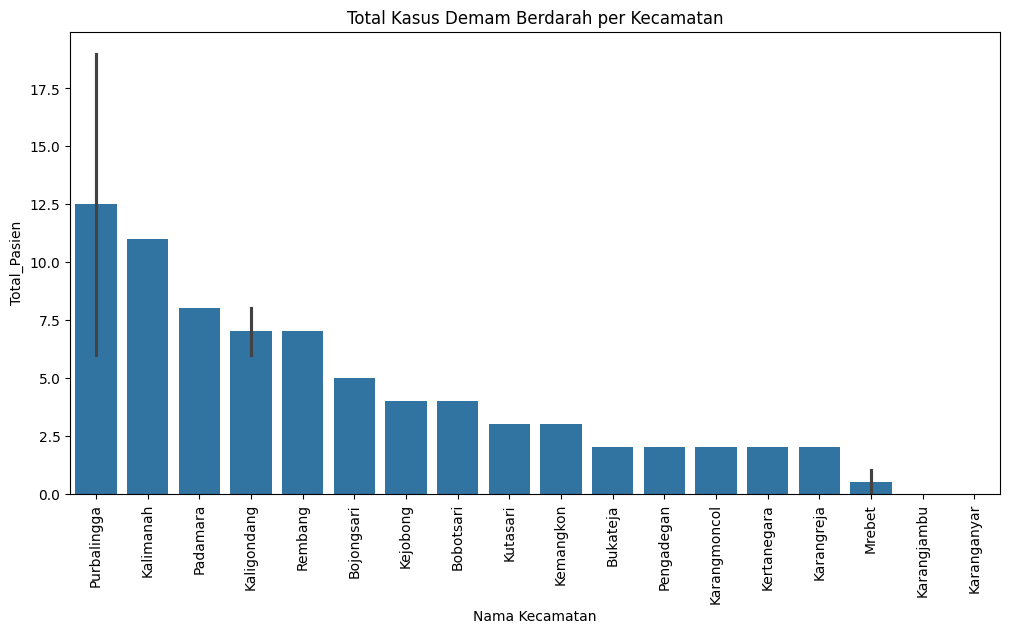

In [8]:
# Visualization 1: Total Cases by District
plt.figure(figsize=(12,6))
sns.barplot(x='Nama Kecamatan', y='Total_Pasien', data=df.sort_values('Total_Pasien', ascending=False))
plt.title('Total Kasus Demam Berdarah per Kecamatan')
plt.xticks(rotation=90)
plt.show()

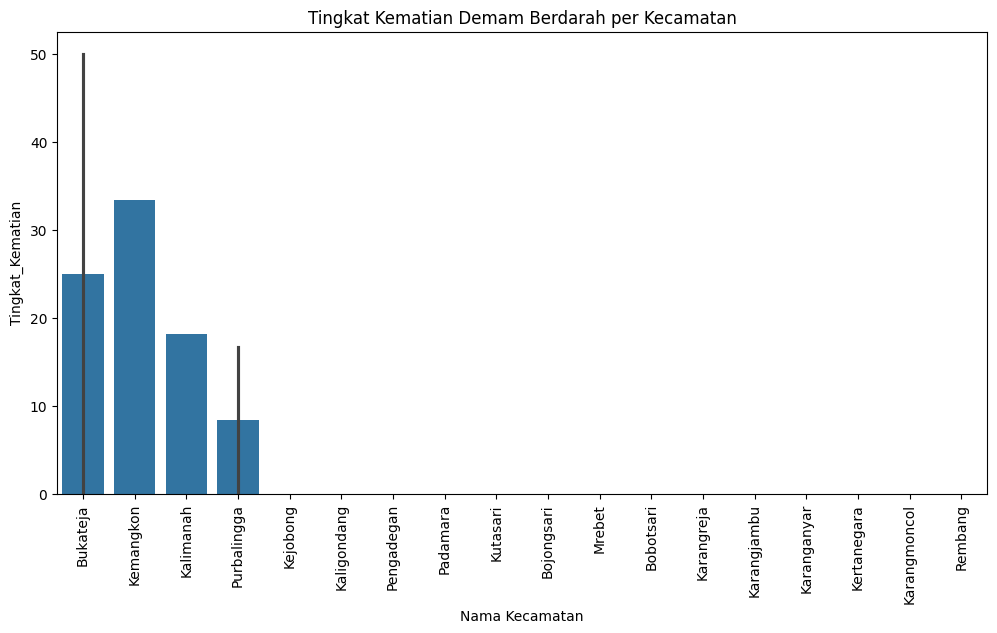

In [9]:
# Visualization 2: Death Rate by District
plt.figure(figsize=(12,6))
sns.barplot(x='Nama Kecamatan', y='Tingkat_Kematian', data=df.sort_values('Tingkat_Kematian', ascending=False))
plt.title('Tingkat Kematian Demam Berdarah per Kecamatan')
plt.xticks(rotation=90)
plt.show()

## Proses Learning/Modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns

In [10]:
# Prepare data for modeling
X = df[['Total_Pasien', 'Jumlah Pasien Laki - laki', 'Jumlah Pasien Perempuan']]
y = (df['Tingkat_Kematian'] > 0).astype(int)

In [14]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
from sklearn.model_selection import StratifiedKFold

# Gunakan stratified k-fold cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

C:\Users\adett\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


# Random Forest Classifier

In [17]:
# Model Training - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [18]:
# Model Evaluation
y_pred_rf = rf_model.predict(X_test)

In [22]:
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



C:\Users\adett\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


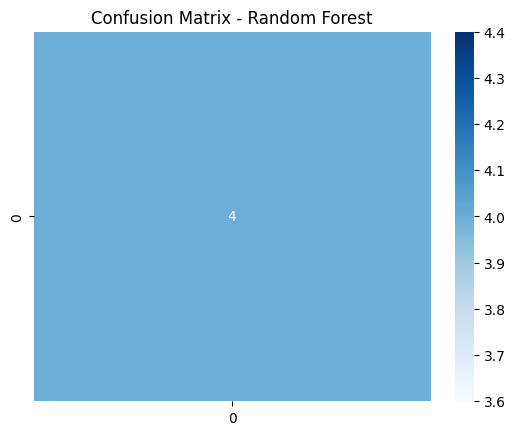

In [23]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Naive Bayes

In [24]:
# Model Training - Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [25]:
# Model Evaluation
y_pred_nb = nb_model.predict(X_test)

In [26]:
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

=== Naive Bayes ===
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



C:\Users\adett\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


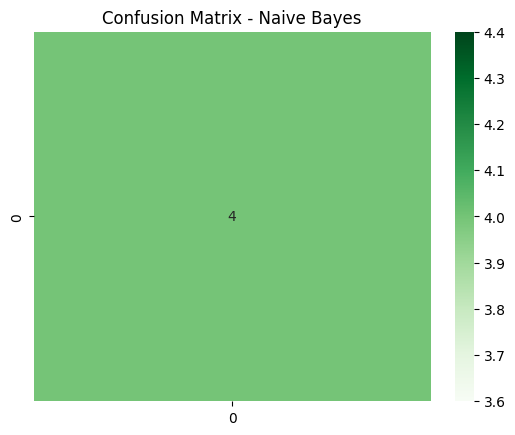

In [27]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# XGBoost

In [28]:
# Model Training - XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
# Model Evaluation
y_pred_xgb = xgb_model.predict(X_test)


In [30]:
print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



C:\Users\adett\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


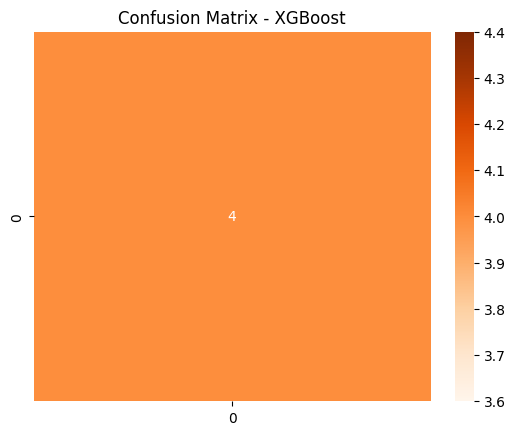

In [31]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.show()

## Performa Model

In [34]:
# Membuat dataframe untuk perbandingan model
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Naive Bayes', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_xgb)
    ]
})

C:\Users\adett\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adett\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adett\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\User

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

In [37]:
# Menampilkan perbandingan
print("=== Perbandingan Performa Model ===")
print(model_comparison)

=== Perbandingan Performa Model ===
           Model  Accuracy  Precision  Recall  F1-Score
0  Random Forest       1.0        0.0     0.0       0.0
1    Naive Bayes       1.0        0.0     0.0       0.0
2        XGBoost       1.0        0.0     0.0       0.0


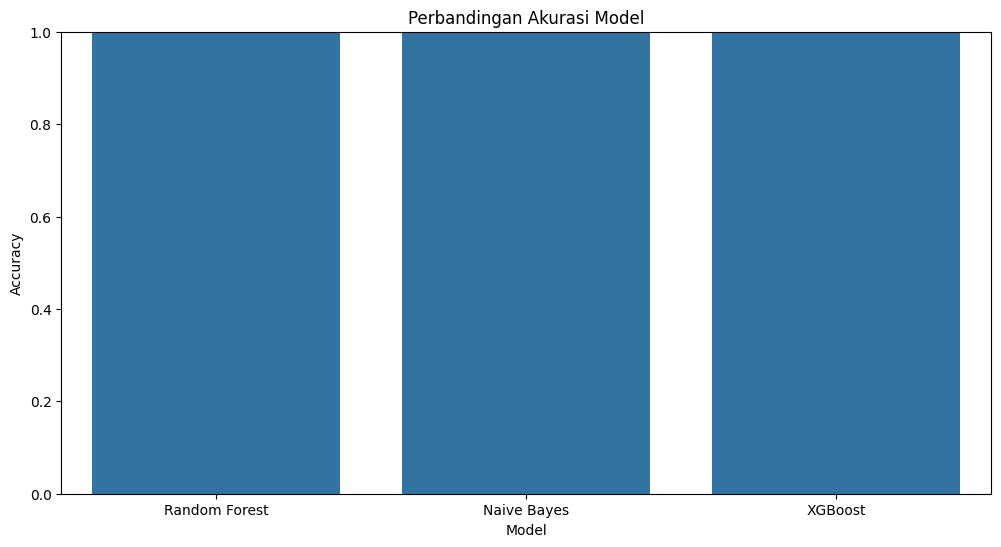

In [38]:
# Visualisasi perbandingan
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=model_comparison)
plt.title('Perbandingan Akurasi Model')
plt.ylim(0, 1)
plt.show()

## Diskusi Hasil dan Kesimpulan

**Hasil :**
- **Random Forest**:
- **Naive Bayes**:[Cenderung lebih cepat tetapi mungkin kurang akurat untuk dataset ini]
- **XGBoost**:[Biasanya memberikan hasil yang sangat kompetitif]

**Kesimpulan:**
- Model terbaik untuk dataset ini adalah [Naive Bayes karena menggunakan dataset kecil]
- Perbedaan performa antar model disebabkan oleh [tingkat akurasi yang didapat dari database]

**Saran:**
- Untuk dataset kecil, Naive Bayes bisa menjadi pilihan karena sederhana dan cepat
- Untuk akurasi lebih tinggi, XGBoost atau Random Forest lebih direkomendasikan
- Hyperparameter tuning bisa dilakukan untuk meningkatkan performa model